# Optimization Methods of GerryChain

<style>
blockquote:has(.notebook-admonition-title) {
  --notebook-admonition-color: var(--color-admonition-title--note, #087fc7);
  --notebook-admonition-title-background:
    var(--color-admonition-title-background--note, rgba(8, 127, 199, 0.18));
  background: var(--color-admonition-background, transparent);
  border: 0;
  border-left: 0.2rem solid var(--notebook-admonition-color);
  border-radius: 0.2rem;
  box-shadow: 0 0.2rem 0.5rem rgba(0, 0, 0, 0.05), 0 0 0.0625rem rgba(0, 0, 0, 0.1);
  font-size: var(--admonition-font-size, 0.8125rem);
  margin: 1rem auto;
  overflow: hidden;
  padding: 0 0.5rem 0.5rem;
}
blockquote:has(.notebook-admonition-title.important) {
  --notebook-admonition-color:
    var(--color-admonition-title--attention, #ff5252);
  --notebook-admonition-title-background:
    var(--color-admonition-title-background--attention, rgba(255, 82, 82, 0.2));
}
blockquote p:has(> .notebook-admonition-title) {
  background: var(--notebook-admonition-title-background);
  font-size: var(--admonition-title-font-size, 0.8125rem);
  font-weight: 500;
  line-height: 1.3;
  margin: 0 -0.5rem 0.5rem;
  padding: 0.4rem 0.5rem 0.4rem 2rem;
  position: relative;
}
blockquote p:has(> .notebook-admonition-title)::before {
  color: var(--notebook-admonition-color);
  content: "✎";
  left: 0.65rem;
  position: absolute;
}
blockquote p:has(> .notebook-admonition-title.important)::before {
  content: "⚠";
}
.notebook-admonition-title {
  font-weight: inherit;
}
</style>

In GerryChain, we provide a class known as the `SingleMetricOptimizer` as well as a
`Gingelator` subclass that allow us to perform optimization runs.


Currently, there are 3 different optimization methods available in GerryChain:

- **Short Bursts**: This method chains together a series of neutral explorers. The main
  idea is to run the chain for a short period of time (short burst) and then continue
  the chain from the partition that maximizes the objective function within the most
  recent short burst. For more information, please refer to
  [this paper](https://arxiv.org/abs/2011.02288).

- **Simulated Annealing**: This method varies the probablity of accepting a worse plan
  according to a temperature schedule which ranges from 0 to 1.

- **Tilted Runs**: This method accepts a worse plan with a fixed probability $p$,
  and always accepts better plans.


While sampling naively with GerryChain can give us an understanding of the neutral
baseline for a state, there are often cases where we want to find plans with
properties that are rare to encounter in a neutral run. Many states have
laws/guidelines that state that plans should be as compact as feasibly possible, maximize
preservation of political boundaries and/or communities of interest; some even look to
minimize double bunking of incumbents or seek proportionality/competitiveness in
contests. Heuristic optimization methods can be used to find example plans with these
properties and to explore the trade-offs between them.


<div align="center">
  <a href="https://github.com/mggg/GerryChain/blob/main/docs/_static/05_bg_census_consolidated.json" class="download-badge" download>
    Download Example File
  </a>
</div>
<br style="line-height: 5px;">


For the first part of this documentation, we will be working with a simple example wherein
we will try to minimize the number of cut edges in a partition. There are, of course
more complex things that we can do here, but the point of this guide is to just get you
used to the API for the `SingleMetricOptimizer` class. As per usual, we will begin
with importing the necessary packages:

In [1]:
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)
from gerrychain.optimization import SingleMetricOptimizer, Gingleator
from gerrychain.partition import recursive_seed_part
from gerrychain.proposals import build_recom_proposal_fn
from functools import partial
import pandas as pd
import json
from networkx.readwrite import json_graph
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random

rng = random.Random(2024)

Since the `SingleMetricOptimizer` class uses ReCom under the hood, we will need to
do a lot of the same setup that we did in [Running a chain with ReCom](./recom.ipynb)
section:

In [2]:
graph = Graph.from_json("05_bg_census_consolidated.json")

POPCOL = "tot_pop_20"
SEN_DISTS = 35
EPS = 0.02
TOTPOP = sum(graph.node_data(node_id)[POPCOL] for node_id in graph.node_indices)

chain_updaters = {
    "population": updaters.Tally(POPCOL, alias="population"),
}

initial_partition = Partition.from_random_assignment(
    graph=graph,
    n_parts=SEN_DISTS,
    epsilon=EPS,
    pop_col=POPCOL,
    updaters=chain_updaters,
    rng=rng,
)

proposal = build_recom_proposal_fn(
    pop_col=POPCOL,
    pop_target=TOTPOP/SEN_DISTS,
    epsilon=EPS,
)

chain_constraints = constraints.within_percent_of_ideal_population(initial_partition, EPS)

## Using `SingleMetricOptimizer`

`SingleMetricOptimizer` is a wrapper around our basic `MarkovChain`
class; to set it up, we simply pass it a proposal function, some constraints, an initial
state, and the objective function of interest:

In [3]:
def num_cut_edges(partition):
    return len(partition["cut_edges"])

optimizer = SingleMetricOptimizer(
    proposal=proposal,
    constraints=chain_constraints,
    initial_state=initial_partition,
    optimization_metric=num_cut_edges,
    maximize=False,
    rng=rng,
)

An important thing to note here is that the objective function that we are passing takes as
input a `Partition` object and returns a float or integer value. In our case, one of the
default updaters for the `Partition` class, `cut_edges`, returns the cut edge set for
the whole partition. With this, we can run each of the optimization methods and collect some data!

> <span class="notebook-admonition-title">Note</span>
>
> We collect data using the syntax `optimizer.best_score`. The `.best_score` property
> of the `SingleMetricOptimizer` just returns the best score that has been observed
> throughout the duration of the optimization process. To evaluate the score of a
> particular partition, we can use the syntax `optimizer.score(partition)`.

In [4]:
total_steps = 5000

# Short Bursts
min_scores_sb = np.zeros(total_steps)
scores_sb = np.zeros(total_steps)
for i, part in enumerate(optimizer.short_bursts(5, 1000, with_progress_bar=False)):
    min_scores_sb[i] = optimizer.best_score
    scores_sb[i] = optimizer.score(part)

# Simulated Annealing
min_scores_anneal = np.zeros(total_steps)
scores_anneal = np.zeros(total_steps)
for i, part in enumerate(
    optimizer.simulated_annealing(
        total_steps,
        optimizer.jumpcycle_beta_function(200, 800),
        beta_magnitude=1,
        with_progress_bar=False
    )
):
    min_scores_anneal[i] = optimizer.best_score
    scores_anneal[i] = optimizer.score(part)

# Tilted Runs
min_scores_tilt = np.zeros(total_steps)
scores_tilt = np.zeros(total_steps)
for i, part in enumerate(optimizer.tilted_run(total_steps, p=0.125, with_progress_bar=False)):
    min_scores_tilt[i] = optimizer.best_score
    scores_tilt[i] = optimizer.score(part)

> <span class="notebook-admonition-title">Note</span>
>
> The step count is reduced from 10000 in the original guide so the
> documentation build stays fast.

We can then plot the results to see how each method performed:

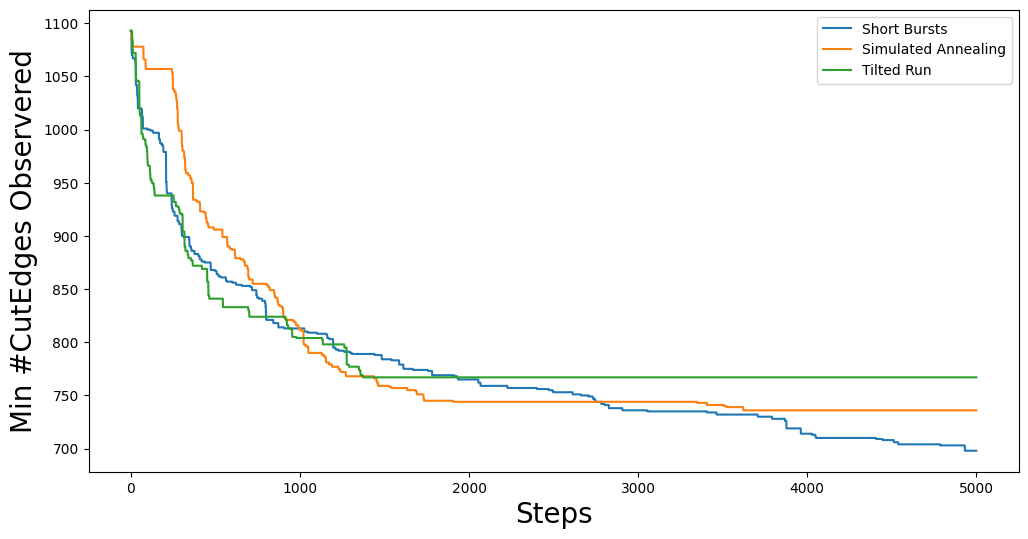

In [5]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(min_scores_sb, label="Short Bursts")
plt.plot(min_scores_anneal, label="Simulated Annealing")
plt.plot(min_scores_tilt, label="Tilted Run")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Min #CutEdges Observered", fontsize=20)
plt.legend()
plt.show()

Of course, the above trace is just shows the progression of the best score as the chain
moves along. If we want to see how the optimization function performs at each step, we can
plot the full trace:

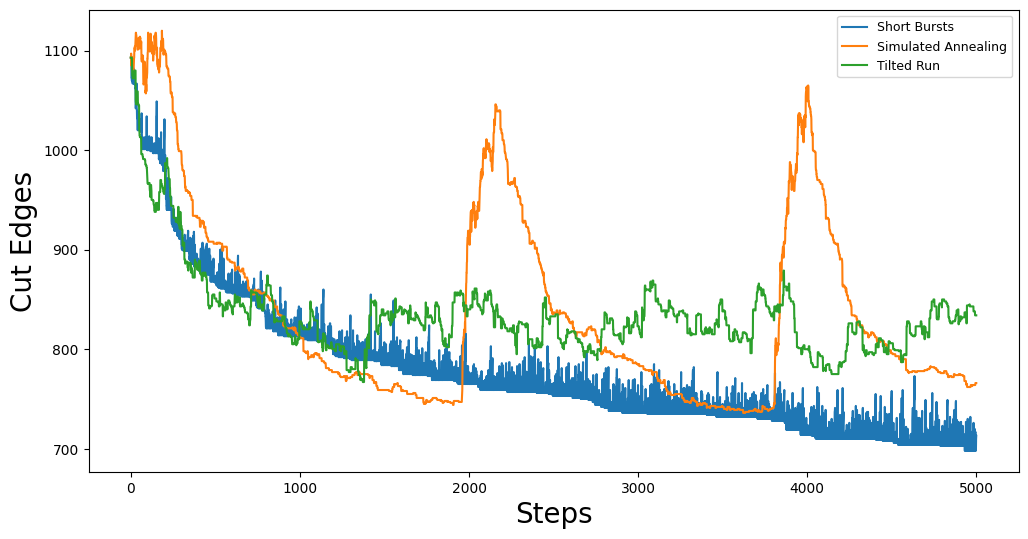

In [6]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(scores_sb, label="Short Bursts")
plt.plot(scores_anneal, label="Simulated Annealing")
plt.plot(scores_tilt, label="Tilted Run")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Cut Edges", fontsize=20)
plt.legend(fontsize=9)
plt.show()

Here we can see some of the quirks of each of the optimization methods. For example,
our simulated annealing method is using a jumpcycle beta function and we can see when
the acceptance rate is high represented by spikes in the trace plot. Short bursts
is generally pretty noisy, but since each burst starts from the best partition in the
previous burst, we see that it has a general downward trend. Lastly, tilted runs
just accept worse partitions with a fixed probability, so the (relatively) uniform volatility
of the cut edge score trace plot is expected.


## Using `Gingleator`

Named for the Supreme Court case *Thornburg v. Gingles*, **Gingles' Districts** are
districts that are 50% + 1 of a minority population subgroup (more colloquially called
majority-minority districts).

`Gingleator` is a subclass of the `SingleMetricOptimizer`. Technically this means that
everything in the `Gingleator` class can also be done using the `SingleMetricOptimizer`
class, but the `Gingleator` class provides some quality-of-life improvements to the user
experience.

For the purposes of this tutorial, we will be using the `Gingleator` class to try and optimize
the number of districts with

1. A majority-minority population for black population (mainly as a warm-up)
2. A majority-minority Voting Age Population (VAP) for black voters

In the provided JSON file (linked in the blue button above), we have included the following
columns aggregated from the 2020 Census data on block groups for the state of Arkansas:

- `tot_pop_20`: Total Population for the block group according to the 2020 Census
- `tot_vap_20`: Total Voting Age Population (18+) for the block group according to the 2020 Census
- `bpop_20`: Total Black Population for the block group according to the 2020 Census
- `bvap_20`: Total Black Voting Age Population (18+) for the block group according to the 2020 Census

> <span class="notebook-admonition-title">Note</span>
>
> Both the `bpop_20` and `bvap_20` columns are "any part black" aggregations acquired
> from the 2020 Census P1 and P3 tables. That is to say, `bpop_20` is the total number of
> people that included "black" as any part of their racial identity when reporting to the
> Census Bureau.

Since the `Gingleator` class is a subclass of `SingleMetricOptimizer`, a lot of the
setup for the optimization process is the same. The main things that we need to be careful of
are the parameters we pass to the `Gingleator` class. Specifically, we need to make updaters
that keep track of the relevant statistics we are optimizing for. In example (1) this means
that we need an updater for the total population (we will just call this `population`) and
the total black population (we will call this `bpop`).


### Majority-Minority Total Population

In [7]:
graph = Graph.from_json("05_bg_census_consolidated.json")

POPCOL = "tot_pop_20"
SEN_DISTS = 35
EPS = 0.02
TOTPOP = sum(graph.node_data(node_id)[POPCOL] for node_id in graph.node_indices)

chain_updaters = {
    "population": updaters.Tally(POPCOL, alias="population"),
    "bpop": updaters.Tally("bpop_20", alias="bpop"),
}

initial_partition = Partition.from_random_assignment(
    graph=graph,
    n_parts=SEN_DISTS,
    epsilon=EPS,
    pop_col=POPCOL,
    updaters=chain_updaters,
    rng=rng,
)

proposal = build_recom_proposal_fn(
    pop_col=POPCOL,
    pop_target=TOTPOP/SEN_DISTS,
    epsilon=EPS,
)

chain_constraints = constraints.within_percent_of_ideal_population(initial_partition, EPS)

There are several parameters that we need to pass to the `Gingleator` class. Most of them
should be familiar at this point, but the following are the most important ones for
understanding appropriate usage of the class:


**Population Parameters of the** `Gingleator` **class**

There are three main population parameters that we can to pass to the `Gingleator` class.
However, depending on which are passed, either one or two of them will be unnecessary.

- (`minority_pop_col`, `total_pop_col`): This pair is passed when the user would like for the `Gingleator` class to compute the percentage of the minority population from quotient of these two updaters. The `total_pop_col` is the name of the **UPDATER** that contains the total population for each partition, and the `minority_pop_col` is the name of the **UPDATER** that contains total population for the minority population of interest. In the case that this pair of parameters is passed, the initialization function will create an updater for `minority_perc_col` via the formula  `minority_pop_col / total_pop_col` for each partition, and the optimization function will then be passed the decimal values to compute the resulting partition's score for each step in the Markov chain.

- The `minority_perc_col` is the name of the **UPDATER** that contains the percentage of the minority population of interest. The updater should already have the score for each part in the partition formatted as a percentage, so the optimization function will process these values as they are passed.

**Score Function of the** `Gingleator` **class**

The `score_function` parameter is a function $f:P \to \mathbb{R}$ that
take in a gerrychain `Partition` object and returns a score for that partition. The
`SingleMetricOptimizer` class also allows for the modification of score functions, but
the `Gingleator` class comes with some nice built-in score functions that are meant to
to be used as good starting points for exploring the space of possible plans.

Let $t$ be the threshold for the score as determined by the user, and let $n$
be the number of districts in a partition $P$ with a minority percentage over the
threshold value $t$, so $n = \sum_{p_i \in P} \mathbb{1}_{p_i\geq t}$ where
$p_i$ is the percentage of the minority population in district $i$.

- `num_opportunity_dists`: Given a `Partition`, this function will return $n$.

- `reward_partial_dist`: Given a `Partition`, this function will return $n + \max(\{p_i : p_i < t\})$.

- `reward_next_highest_close`: Given a `Partition`, let $p_k = \max(\{p_i : p_i < t\})$. This function will return $n$ if $p_k + 0.1 < t$ and $n + 10(p_k - t + 0.1)$ otherwise.

- `penalize_maximum_over`: Given a `Partition`, this function will return 0 if $n = 0$ and $n + \frac{1-\max(\{p_i\})}{1-t}$ otherwise.

- `penalize_avg_over`: Given a `Partition`, this function will return 0 if $n = 0$ and $n + \frac{1-avg(\{p_i: p_i \geq t\})}{1-t}$ otherwise.


We are now prepared to instantiate the `Gingleator` class:

In [8]:
gingles = Gingleator(
    proposal,
    chain_constraints,
    initial_partition,
    minority_pop_col='bpop',
    total_pop_col='population',
    score_function=Gingleator.reward_partial_dist,
    rng=rng,
)

Since the `Gingleator` class is a subclass of the `SingleMetricOptimizer` class, we can
use the same optimization methods as before:

In [9]:
total_steps = 5000

# Short Bursts
max_scores_sb = np.zeros(total_steps)
scores_sb = np.zeros(total_steps)
for i, part in enumerate(gingles.short_bursts(10, 500, with_progress_bar=False)):
    max_scores_sb[i] = gingles.best_score
    scores_sb[i] = gingles.score(part)

# Simulated Annealing
max_scores_anneal = np.zeros(total_steps)
scores_anneal = np.zeros(total_steps)
for i, part in enumerate(
    gingles.simulated_annealing(
        total_steps,
        gingles.jumpcycle_beta_function(1000, 4000),
        beta_magnitude=500,
        with_progress_bar=False
    )
):
    max_scores_anneal[i] = gingles.best_score
    scores_anneal[i] = gingles.score(part)

# Tilted Runs
max_scores_tilt = np.zeros(total_steps)
scores_tilt = np.zeros(total_steps)
for i, part in enumerate(gingles.tilted_run(total_steps, 0.125, with_progress_bar=False)):
    max_scores_tilt[i] = gingles.best_score
    scores_tilt[i] = gingles.score(part)

> <span class="notebook-admonition-title">Note</span>
>
> The step count is reduced from 10000 in the original guide so the
> documentation build stays fast.

And we can plot the results again:

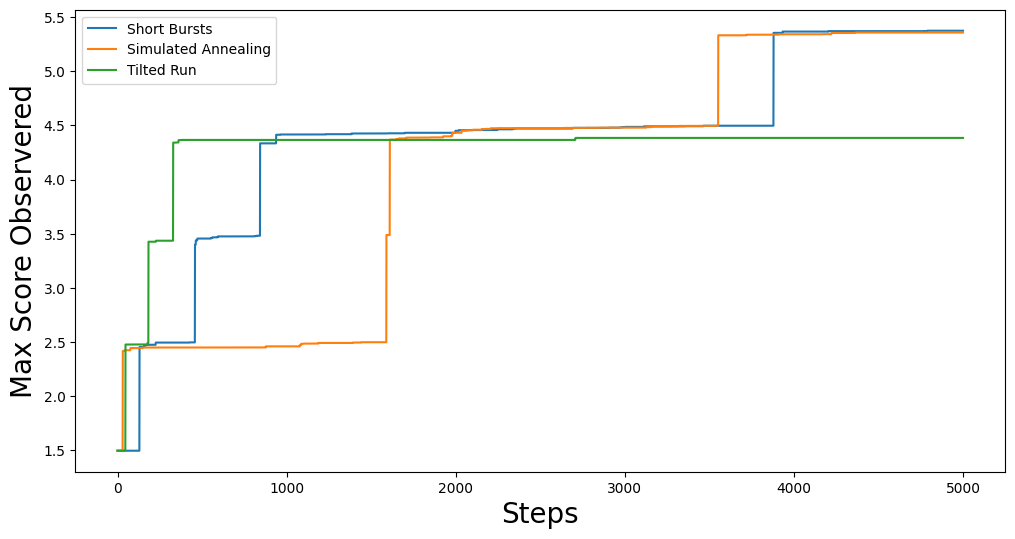

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(max_scores_sb, label="Short Bursts")
plt.plot(max_scores_anneal, label="Simulated Annealing")
plt.plot(max_scores_tilt, label="Tilted Run")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Max Score Observered", fontsize=20)
plt.legend()
plt.show()

Great! We have successfully used the `Gingleator` class to optimize the number of districts
with a majority-minority population for black population. Now, we can do the same thing for
for the majority-minority Voting Age Population (VAP) for black voters.

### Majority-Minority Voting Age Population

The astute reader will probably notice pretty quickly that there is a very easy way to modify
the code from the previous section to optimize for Majority-Minority VAP. Indeed, all we need
to do is change our updaters to be

In [11]:
chain_updaters = {
    "population": updaters.Tally(POPCOL, alias="population"),
    "vap": updaters.Tally("tot_vap_20", alias="vap"),
    "bvap": updaters.Tally("bvap_20", alias="bvap"),
}

initial_partition = Partition.from_random_assignment(
    graph=graph,
    n_parts=SEN_DISTS,
    epsilon=EPS,
    pop_col=POPCOL,
    updaters=chain_updaters,
    rng=rng,
)

chain_constraints = constraints.within_percent_of_ideal_population(initial_partition, EPS)

and then change our `Gingleator` class instantiation to be

In [12]:
gingles = Gingleator(
    proposal,
    chain_constraints,
    initial_partition,
    minority_pop_col='bvap',
    total_pop_col='vap',
    score_function=Gingleator.reward_partial_dist,
    rng=rng,
)

and we will be off to the races. In the interest of being thorough, however, let us see how to
modify this code to make use of the `minority_perc_col` parameter of the `Gingleator` class.
For this, we will just need to tweak our updaters a little bit:

In [13]:
graph = Graph.from_json("05_bg_census_consolidated.json")

POPCOL = "tot_pop_20"
SEN_DISTS = 35
EPS = 0.02
TOTPOP = sum(graph.node_data(node_id)[POPCOL] for node_id in graph.node_indices)


# Updaters take in partitions and then return some value. In this case, we
# want to return a dictionary of mapping each part in the partition to the value BVAP/VAP
def compute_bvap_pct(partition):
    percent_by_part = {}
    for part in partition.parts:
        # bvap and vap are dictionaries mapping each partition part to
        # it corresponding BVAP or VAP tally respectively
        percent_by_part[part] = partition["bvap"][part] / partition["vap"][part]
    return percent_by_part

chain_updaters = {
    "population": updaters.Tally(POPCOL, alias="population"),
    "vap": updaters.Tally("tot_vap_20", alias="vap"),
    "bvap": updaters.Tally("bvap_20", alias="bvap"),
    "bvap_pct": compute_bvap_pct
}

initial_partition = Partition.from_random_assignment(
    graph=graph,
    n_parts=SEN_DISTS,
    epsilon=EPS,
    pop_col=POPCOL,
    updaters=chain_updaters,
    rng=rng,
)

proposal = build_recom_proposal_fn(
    pop_col=POPCOL,
    pop_target=TOTPOP/SEN_DISTS,
    epsilon=EPS,
)

chain_constraints = constraints.within_percent_of_ideal_population(initial_partition, EPS)

In [14]:
gingles = Gingleator(
    proposal,
    chain_constraints,
    initial_partition,
    minority_perc_col='bvap_pct',
    score_function=Gingleator.reward_partial_dist,
    rng=rng,
)

In [15]:
total_steps = 5000

# Short Bursts
max_scores_sb = np.zeros(total_steps)
scores_sb = np.zeros(total_steps)
for i, part in enumerate(gingles.short_bursts(10, 500, with_progress_bar=False)):
    max_scores_sb[i] = gingles.best_score
    scores_sb[i] = gingles.score(part)

# Simulated Annealing
max_scores_anneal = np.zeros(total_steps)
scores_anneal = np.zeros(total_steps)
for i, part in enumerate(
    gingles.simulated_annealing(
        total_steps,
        gingles.jumpcycle_beta_function(1000, 4000),
        beta_magnitude=500,
        with_progress_bar=False
    )
):
    max_scores_anneal[i] = gingles.best_score
    scores_anneal[i] = gingles.score(part)

# Tilted Runs
max_scores_tilt = np.zeros(total_steps)
scores_tilt = np.zeros(total_steps)
for i, part in enumerate(gingles.tilted_run(total_steps, 0.125, with_progress_bar=False)):
    max_scores_tilt[i] = gingles.best_score
    scores_tilt[i] = gingles.score(part) 

> <span class="notebook-admonition-title">Note</span>
>
> The step count is reduced from 10000 in the original guide so the
> documentation build stays fast.

And now we plot the results again!

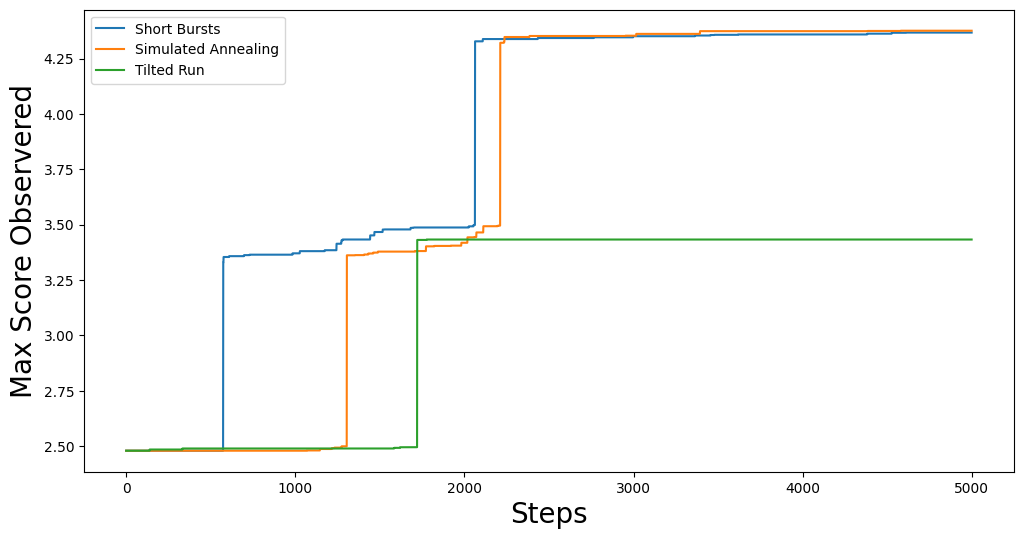

In [16]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(max_scores_sb, label="Short Bursts")
plt.plot(max_scores_anneal, label="Simulated Annealing")
plt.plot(max_scores_tilt, label="Tilted Run")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Max Score Observered", fontsize=20)
plt.legend()
plt.show()